# Define the seeds

In [1]:
import random
import os
import numpy as np

pi_digit_string = "1415926535897932384626433832795028841971"
seeds= [int(pi_digit_string[i:i+2]) for i in range(0, len(pi_digit_string), 2)]
print(len(seeds), seeds)

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

# Set the seed for reproducibility
set_seed(seeds[0])

20 [14, 15, 92, 65, 35, 89, 79, 32, 38, 46, 26, 43, 38, 32, 79, 50, 28, 84, 19, 71]


# Preprocessing, including normalizing and augmenting data!

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import sys
sys.path.append("../preprocessing")
from augmenter import Augmenter, augment_rf_data 

# Load full combined dataset
df = pd.read_csv("../preprocessing/ready/squat_dataset_3d_raw.csv")

# Only keep columns that are NOT angles and are NOT the label
feature_cols = [col for col in df.columns if "angle" not in col and col != "label"]

# Now extract filtered features and labels
X = df[feature_cols].values
y = df["label"].values

# Train/test split
X_train_raw, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seeds[0] 
)

# Normalize using only training data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)  # Normalize training data
X_test = scaler.transform(X_test)

# Augment only the training set
augmenter = Augmenter(noise_std=0.05, noise_n=2)  # Now suitable for normalized data
X_train, y_train = augment_rf_data(X_train, y_train, augmenter, base_seed=seeds[0])

# Final stats
print(f"\n Loaded and split: {len(X_train)} training samples, {len(X_test)} test samples")
print(f" Using {len(feature_cols)} features")


 Loaded and split: 603 training samples, 51 test samples
 Using 96 features


# Preprocessing with original data import

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Load full combined dataset
df = pd.read_csv("../preprocessing/ready/squat_dataset_3d_raw.csv")

# Select feature columns, excluding any with "angle" in the name
feature_cols = [col for col in df.columns if col != "label" and "angle" not in col.lower()]

# Split into features and labels
X = df[feature_cols]
y = df["label"]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seeds[0]
)

# Confirm
print(f" Loaded and split: {len(X_train)} training samples, {len(X_test)} test samples")
print(f" Using {len(feature_cols)} features (excluding angles):\n{feature_cols}")


 Loaded and split: 201 training samples, 51 test samples
 Using 96 features (excluding angles):
['left_hip_x_mean', 'left_hip_x_std', 'left_hip_x_min', 'left_hip_x_max', 'left_hip_y_mean', 'left_hip_y_std', 'left_hip_y_min', 'left_hip_y_max', 'left_hip_z_mean', 'left_hip_z_std', 'left_hip_z_min', 'left_hip_z_max', 'right_hip_x_mean', 'right_hip_x_std', 'right_hip_x_min', 'right_hip_x_max', 'right_hip_y_mean', 'right_hip_y_std', 'right_hip_y_min', 'right_hip_y_max', 'right_hip_z_mean', 'right_hip_z_std', 'right_hip_z_min', 'right_hip_z_max', 'left_knee_x_mean', 'left_knee_x_std', 'left_knee_x_min', 'left_knee_x_max', 'left_knee_y_mean', 'left_knee_y_std', 'left_knee_y_min', 'left_knee_y_max', 'left_knee_z_mean', 'left_knee_z_std', 'left_knee_z_min', 'left_knee_z_max', 'right_knee_x_mean', 'right_knee_x_std', 'right_knee_x_min', 'right_knee_x_max', 'right_knee_y_mean', 'right_knee_y_std', 'right_knee_y_min', 'right_knee_y_max', 'right_knee_z_mean', 'right_knee_z_std', 'right_knee_z_min',

# Cross-Validation with Best Parameters Logging

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import math

# Define your hyperparameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [
        int(math.sqrt(X_train.shape[1])),
        int(2 * math.sqrt(X_train.shape[1])),
        int(3 * math.sqrt(X_train.shape[1])),
        None
    ],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seeds[0])

# Initialize model
rf = RandomForestClassifier(random_state=seeds[0])

# Run Grid Search CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Print best results
print(f"\n Best Parameters: {grid_search.best_params_}")
print(f" Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")

# View top results
results_df = pd.DataFrame(grid_search.cv_results_).sort_values(by="mean_test_score", ascending=False)
print(results_df[["mean_test_score", "std_test_score", "params"]].head())

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

✅ Best Parameters: {'max_depth': 9, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
✅ Best Cross-Validated Accuracy: 0.9934
     mean_test_score  std_test_score  \
109         0.993361        0.008131   
28          0.993361        0.006229   
271         0.993361        0.008131   
110         0.993361        0.008131   
272         0.993361        0.008131   

                                                params  
109  {'max_depth': 19, 'max_features': 'log2', 'min...  
28   {'max_depth': 9, 'max_features': 'log2', 'min_...  
271  {'max_depth': None, 'max_features': 'log2', 'm...  
110  {'max_depth': 19, 'max_features': 'log2', 'min...  
272  {'max_depth': None, 'max_features': 'log2', 'm...  


# Train the Final Model

In [8]:
top_results = results_df[["mean_test_score", "std_test_score", "params"]].head()
for idx, row in top_results.iterrows():
    print(f"\nAccuracy: {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")
    print("Params:")
    for k, v in row["params"].items():
        print(f"  {k}: {v}")


Accuracy: 0.9934 ± 0.0081
Params:
  max_depth: 19
  max_features: log2
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 300

Accuracy: 0.9934 ± 0.0062
Params:
  max_depth: 9
  max_features: log2
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 300

Accuracy: 0.9934 ± 0.0081
Params:
  max_depth: None
  max_features: log2
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 300

Accuracy: 0.9934 ± 0.0081
Params:
  max_depth: 19
  max_features: log2
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 500

Accuracy: 0.9934 ± 0.0081
Params:
  max_depth: None
  max_features: log2
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 500


#  Evaluate the Model

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import json

best_params = {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

# Store metrics
results = defaultdict(list)

# Evaluate on multiple test splits using different seeds
for seed in seeds:
    print(f"\n Evaluating with test split from seed {seed}")
    set_seed(seed)

    # Resplit data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )

    # Normalize using only training data
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)  # Normalize training data
    X_test = scaler.transform(X_test)

    # Augment only the training set
    #augmenter = Augmenter(noise_std=0.05, noise_n=2)  # Now suitable for normalized data
    #X_train, y_train = augment_rf_data(X_train, y_train, augmenter, base_seed=seed)
    

    best_rf = RandomForestClassifier(**best_params, random_state=seed)
    best_rf.fit(X_train, y_train)

    # Predict labels and probabilities
    y_pred = best_rf.predict(X_test)
    y_proba = best_rf.predict_proba(X_test)[:, 1]

    # Compute metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Store standard metrics
    results["accuracy"].append(report["accuracy"])
    results["precision"].append(report["1"]["precision"])
    results["recall"].append(report["1"]["recall"])
    results["f1"].append(report["1"]["f1-score"])
    results["roc_auc"].append(roc_auc)

    # Store confusion matrix components
    results["tp"].append(cm[1, 1])
    results["fn"].append(cm[1, 0])
    results["fp"].append(cm[0, 1])
    results["tn"].append(cm[0, 0])

#  Summary
print("\n Final evaluation over multiple test splits:")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    values = results[metric]
    print(f"{metric.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

#  Average Confusion Matrix
avg_cm = np.array([
    [np.mean(results["tn"]), np.mean(results["fp"])],
    [np.mean(results["fn"]), np.mean(results["tp"])]
]).round().astype(int)

print("\n Mean Confusion Matrix (rounded):")
print(avg_cm)


# Save results to disk for later statistical testing
with open("rf_raw_accuracy.json", "w") as f:
    json.dump(results["accuracy"], f)


 Evaluating with test split from seed 14

 Evaluating with test split from seed 15

 Evaluating with test split from seed 92

 Evaluating with test split from seed 65

 Evaluating with test split from seed 35

 Evaluating with test split from seed 89

 Evaluating with test split from seed 79

 Evaluating with test split from seed 32

 Evaluating with test split from seed 38

 Evaluating with test split from seed 46

 Evaluating with test split from seed 26

 Evaluating with test split from seed 43

 Evaluating with test split from seed 38

 Evaluating with test split from seed 32

 Evaluating with test split from seed 79

 Evaluating with test split from seed 50

 Evaluating with test split from seed 28

 Evaluating with test split from seed 84

 Evaluating with test split from seed 19

 Evaluating with test split from seed 71

 Final evaluation over multiple test splits:
Accuracy  : 0.9676 ± 0.0279
Precision : 0.9547 ± 0.0391
Recall    : 0.9820 ± 0.0296
F1        : 0.9677 ± 0.0278
Ro

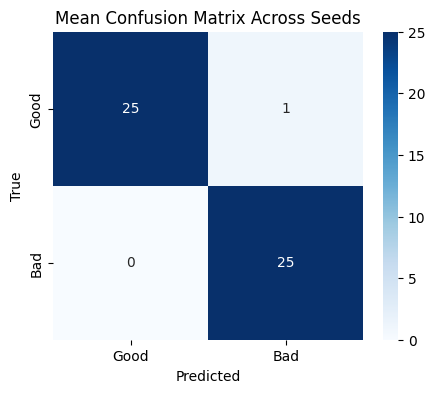

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(avg_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Mean Confusion Matrix Across Seeds")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0.5, 1.5], ["Good", "Bad"])
plt.yticks([0.5, 1.5], ["Good", "Bad"])
plt.show()

Seed 14
Seed 15
Seed 92
Seed 65
Seed 35
Seed 89
Seed 79
Seed 32
Seed 38
Seed 46
Seed 26
Seed 43
Seed 38
Seed 32
Seed 79
Seed 50
Seed 28
Seed 84
Seed 19
Seed 71


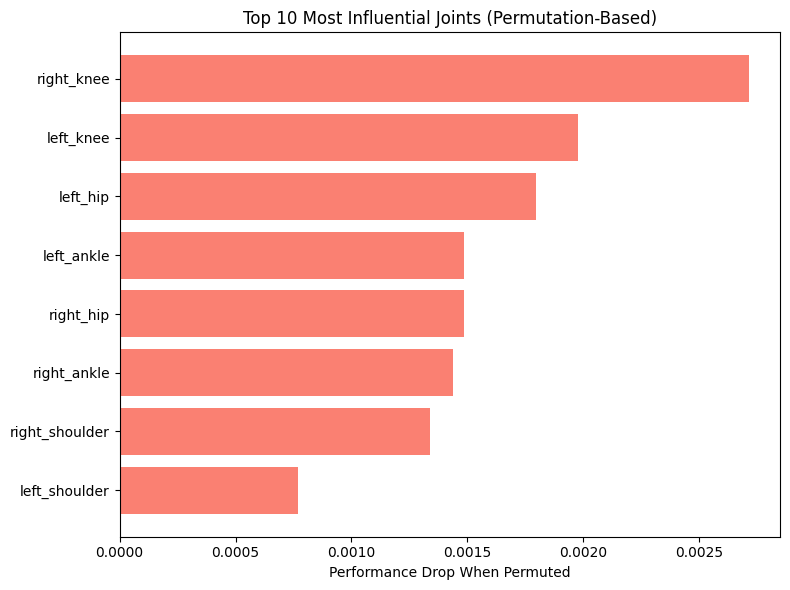

In [3]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import defaultdict
from sklearn.preprocessing import MinMaxScaler

# Your best parameters
best_params = {
    'max_depth': 9,
    'max_features': 'log2',
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 300
}

# Store importances per seed
all_importances = []

for seed in seeds:
    print(f"Seed {seed}")
    set_seed(seed)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )

    # Normalize using only training data
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)  # Normalize training data
    X_test = scaler.transform(X_test)

    # Augment only the training set
    augmenter = Augmenter(noise_std=0.05, noise_n=2)  # Now suitable for normalized data
    X_train, y_train = augment_rf_data(X_train, y_train, augmenter, base_seed=seed)

    # Train Random Forest
    model = RandomForestClassifier(**best_params, random_state=seed)
    model.fit(X_train, y_train)

    # Permutation importance on test set
    result = permutation_importance(
        model, X_test, y_test, scoring="accuracy", n_repeats=5, random_state=seed
    )

    all_importances.append(result.importances_mean)

# === Average across seeds
mean_importance = np.mean(np.stack(all_importances), axis=0)
feature_names = feature_cols[:mean_importance.shape[0]]

# === Group by joint prefix (e.g. left_knee, right_ankle)
grouped_importance = defaultdict(list)
for name, imp in zip(feature_names, mean_importance):
    parts = name.split("_")
    group = f"{parts[0]}_{parts[1]}" if len(parts) >= 2 else parts[0]
    grouped_importance[group].append(imp)

# === Average importance per joint group
grouped_avg = {joint: np.mean(imps) for joint, imps in grouped_importance.items()}
sorted_grouped = sorted(grouped_avg.items(), key=lambda x: x[1], reverse=True)

# === Plot
joints, importances = zip(*sorted_grouped[:10])  # top 10
plt.figure(figsize=(8, 6))
plt.barh(joints[::-1], importances[::-1], color="salmon")
plt.xlabel("Performance Drop When Permuted")
plt.title("Top 10 Most Influential Joints (Permutation-Based)")
plt.tight_layout()
plt.show()
